In [9]:
## 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [10]:
## 2. Chargement et exploration du dataset

df = pd.read_csv("/content/student_habits_performance.csv")
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [11]:
df.shape

(1000, 16)

In [12]:
## 3a. Suppression de l'identifiant et imputation des manquants

df = df.drop(columns=['student_id'])

num_cols = df.select_dtypes(include='number')
cat_cols = df.select_dtypes(include='object')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Valeurs manquantes après imputation :", df.isnull().sum().sum())


Valeurs manquantes après imputation : 0


In [13]:
## Encodage des variables catégorielles

cat_cols=pd.get_dummies(cat_cols, drop_first=True)
df = pd.concat([num_cols, cat_cols], axis=1)

In [14]:
df.shape

(1000, 19)

In [16]:

X = df.drop(columns=['exam_score']).values
y = df['exam_score'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation des features (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTaille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")




Taille train : (800, 18)
Taille test  : (200, 18)


In [17]:
## 4. Définition du modèle (régression)

model = keras.Sequential([
    # Couche d'entrée + 1ère couche cachée
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],), name='couche_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    # 2ème couche cachée
    layers.Dense(64, activation='relu', name='couche_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.2, name='dropout_2'),

    # 3ème couche cachée
    layers.Dense(32, activation='relu', name='couche_3'),

    # Couche de sortie : 1 neurone linéaire (régression → prédiction de exam_score)
    layers.Dense(1, activation='linear', name='sortie')
], name='reseau_exam_score')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "reseau_exam_score"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_1 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
## 5. Compilation et entraînement

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nEntraînement terminé.")


Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5206.4341 - mae: 70.1530 - val_loss: 4853.6353 - val_mae: 67.7379 - learning_rate: 0.0010
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5011.3394 - mae: 68.8530 - val_loss: 4784.9844 - val_mae: 67.2680 - learning_rate: 0.0010
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4793.2007 - mae: 67.3858 - val_loss: 4677.5244 - val_mae: 66.5482 - learning_rate: 0.0010
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4500.9780 - mae: 65.3704 - val_loss: 4488.1626 - val_mae: 65.2735 - learning_rate: 0.0010
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4114.7354 - mae: 62.6509 - val_loss: 4197.1426 - val_mae: 63.2827 - learning_rate: 0.0010
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3606.6362 - mae: 58.8003 - val_loss: 3763.6328 - val_mae: 60.1650 - learning_rate: 0.0010
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3028.7463 - mae: 53.8485 - val_loss: 3174.2371

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
MAE  (Erreur absolue moyenne) : 4.37
RMSE (Racine MSE)             : 5.62
R2 Score : 0.88


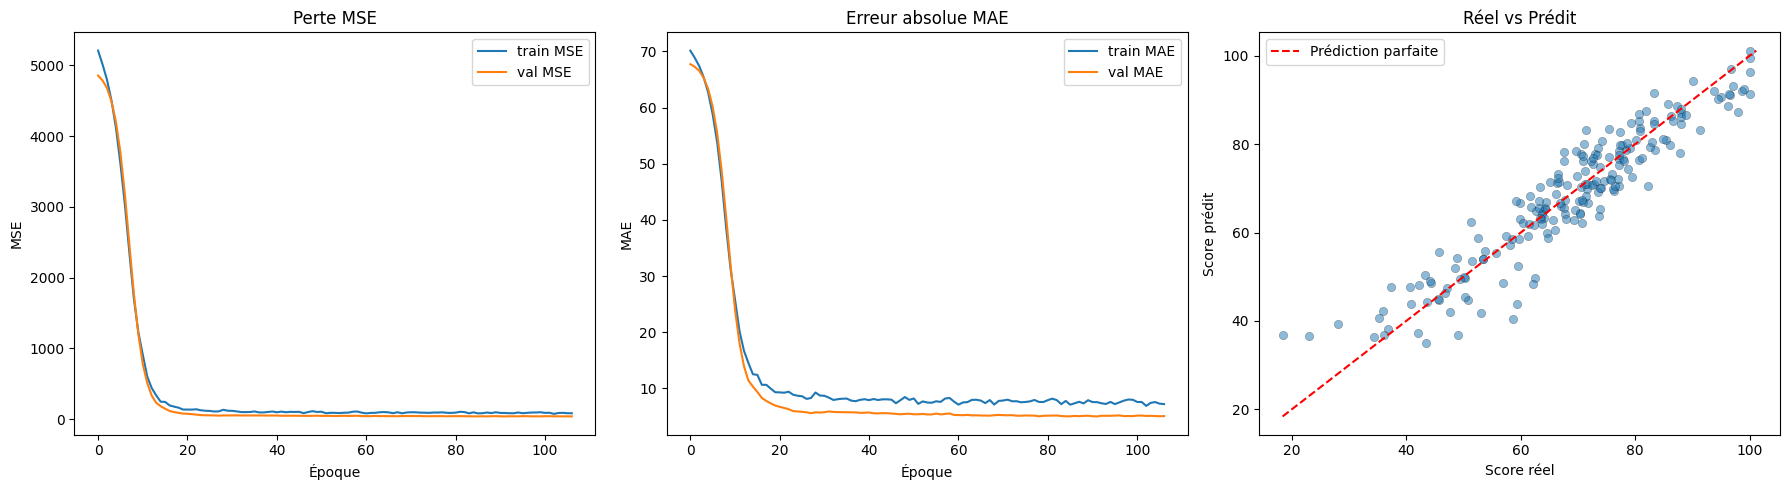

In [24]:
## 6. Évaluation et visualisation
from sklearn.metrics import r2_score

# --- Prédictions sur le jeu de test ---
y_pred = model.predict(X_test).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)

print(f"MAE  (Erreur absolue moyenne) : {mae:.2f}")
print(f"RMSE (Racine MSE)             : {rmse:.2f}")
print(f"R2 Score : {round(r2,2)}")

# --- Visualisations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe de perte (MSE)
axes[0].plot(history.history['loss'],     label='train MSE')
axes[0].plot(history.history['val_loss'], label='val MSE')
axes[0].set_title('Perte MSE')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('MSE')
axes[0].legend()


# Courbe MAE
axes[1].plot(history.history['mae'],     label='train MAE')
axes[1].plot(history.history['val_mae'], label='val MAE')
axes[1].set_title('Erreur absolue MAE')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('MAE')
axes[1].legend()


# Valeurs réelles vs prédites
axes[2].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[2].plot(lims, lims, 'r--', label='Prédiction parfaite')
axes[2].set_title('Réel vs Prédit')
axes[2].set_xlabel('Score réel')
axes[2].set_ylabel('Score prédit')
axes[2].legend()


plt.tight_layout()
plt.show()
